In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv("Kaggle_Ecommerce Data.csv")

In [12]:
df.shape

(34500, 19)

In [13]:
df.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivered_date,region,returned,request_date,return_reason,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,23/12/2023,27/12/2023,West,No,NaN,NaN,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,3/4/2025,9/4/2025,South,No,NaN,NaN,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,8/10/2024,12/10/2024,North,No,NaN,NaN,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,14/9/2024,20/9/2024,South,No,NaN,NaN,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,21/12/2024,27/12/2024,East,No,NaN,NaN,13.88,2.74,1.15,39,Male


In [14]:
df.info()
df.describe()
df['returned'].value_counts()
df['returned'].value_counts(normalize=True)*100

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_id         34500 non-null  object 
 1   customer_id      34500 non-null  object 
 2   product_id       34500 non-null  object 
 3   category         34500 non-null  object 
 4   price            34500 non-null  float64
 5   discount         34500 non-null  float64
 6   quantity         34500 non-null  int64  
 7   payment_method   34500 non-null  object 
 8   order_date       34500 non-null  object 
 9   delivered_date   34500 non-null  object 
 10  region           34500 non-null  object 
 11  returned         34500 non-null  object 
 12  request_date     1903 non-null   object 
 13  return_reason    1903 non-null   object 
 14  total_amount     34500 non-null  float64
 15  shipping_cost    34500 non-null  float64
 16  profit_margin    34500 non-null  float64
 17  customer_age

,proportion
returned,
No,94.484058
Yes,5.515942


In [15]:
df.isnull().sum()

,0
order_id,0
customer_id,0
product_id,0
category,0
price,0
discount,0
quantity,0
payment_method,0
order_date,0
delivered_date,0


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.columns.tolist()

['order_id',
 'customer_id',
 'product_id',
 'category',
 'price',
 'discount',
 'quantity',
 'payment_method',
 'order_date',
 'delivered_date',
 'region',
 'returned',
 'request_date',
 'return_reason',
 'total_amount',
 'shipping_cost',
 'profit_margin',
 'customer_age',
 'customer_gender']

In [18]:
df['returned'].value_counts()

,count
returned,
No,32597
Yes,1903


In [19]:
df['returned'] = df['returned'].map({
    'No': 0,
    'Yes': 1
})

In [20]:
df['returned'].head()

,returned
0,0
1,0
2,0
3,0
4,0


In [21]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

df['delivered_date'] = pd.to_datetime(df['delivered_date'], dayfirst=True)

It only converts the columns internally coz dates are probably in this format:
15/03/2025
DD/MM/YYYY

But Pandas is assuming: MM/DD/YYYY

In [22]:
df[['order_date','delivered_date']].head()

,order_date,delivered_date
0,2023-12-23,2023-12-27
1,2025-04-03,2025-04-09
2,2024-10-08,2024-10-12
3,2024-09-14,2024-09-20
4,2024-12-21,2024-12-27


In [23]:
df['delivery_days'] = (
    df['delivered_date'] - df['order_date']
).dt.days

In [24]:
df[['delivery_days']].head()

,delivery_days
0,4
1,6
2,4
3,6
4,6


In [25]:
df.drop(['order_date','delivered_date'], axis=1, inplace=True)

In [26]:
df.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,region,returned,request_date,return_reason,total_amount,shipping_cost,profit_margin,customer_age,customer_gender,delivery_days
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,West,0,NaN,NaN,139.47,7.88,31.17,60,Female,4
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,South,0,NaN,NaN,24.73,4.60,-2.62,37,Male,6
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,North,0,NaN,NaN,166.80,6.58,13.44,34,Male,4
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,South,0,NaN,NaN,63.67,5.50,2.14,21,Female,6
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,East,0,NaN,NaN,13.88,2.74,1.15,39,Male,6


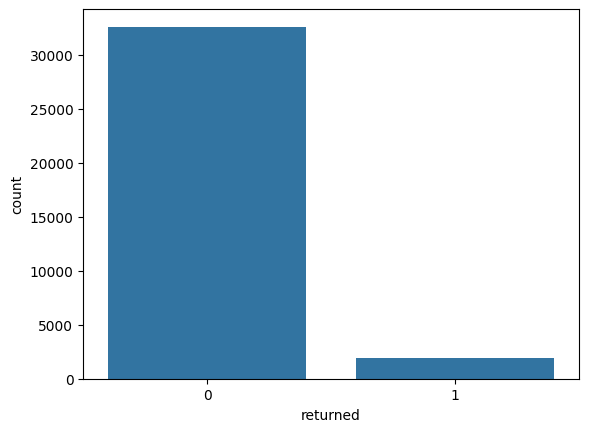

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='returned', data=df)
plt.show()

Out of 34,500 orders, approximately 94.5% were not returned while 5.5% were returned. This indicates that returns are relatively rare, making this an imbalanced classification problem.

In [28]:
pd.crosstab(
    df['category'],
    df['returned'],
    normalize='index'
)*100

returned,0,1
category,,
Beauty,96.222276,3.777724
Electronics,92.702265,7.297735
Fashion,91.717301,8.282699
Grocery,98.693938,1.306062
Home,94.350282,5.649718
Sports,95.061136,4.938864
Toys,95.055333,4.944667


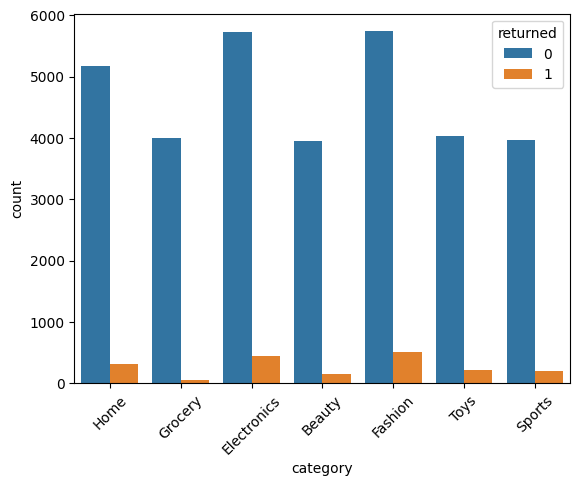

In [29]:
sns.countplot(
    x='category',
    hue='returned',
    data=df
)
plt.xticks(rotation=45)
plt.show()

The highest return percentage was observed in the Fashion category at 8.7%, while the lowest was in Grocery at 1.4%. This suggests that product category significantly influences return behavior.

In [30]:
pd.crosstab(
    df['payment_method'],
    df['returned'],
    normalize='index'
)*100

returned,0,1
payment_method,,
COD,94.903846,5.096154
Credit Card,94.453574,5.546426
Debit Card,94.332745,5.667255
PayPal,94.221835,5.778165
UPI,94.610202,5.389798
Wallet,94.624697,5.375303


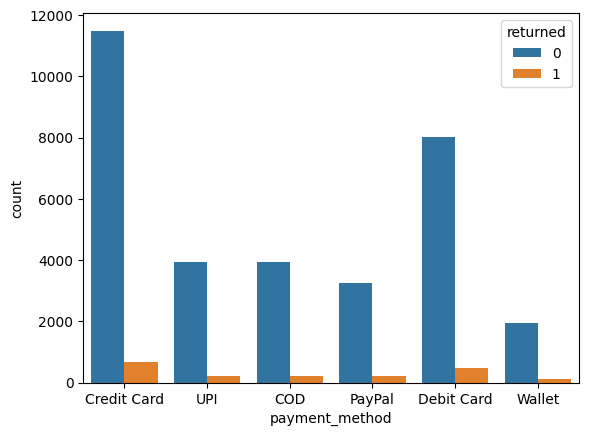

In [31]:
sns.countplot(
    x='payment_method',
    hue='returned',
    data=df
)
plt.show()

Customers using Credit Card payment method showed the highest return rate of 34%, indicating that payment preferences may be associated with return behavior

In [32]:
pd.crosstab(
    df['region'],
    df['returned'],
    normalize='index'
)*100

returned,0,1
region,,
Central,94.904119,5.095881
East,94.090382,5.909618
North,94.638141,5.361859
South,94.316983,5.683017
West,94.550529,5.449471


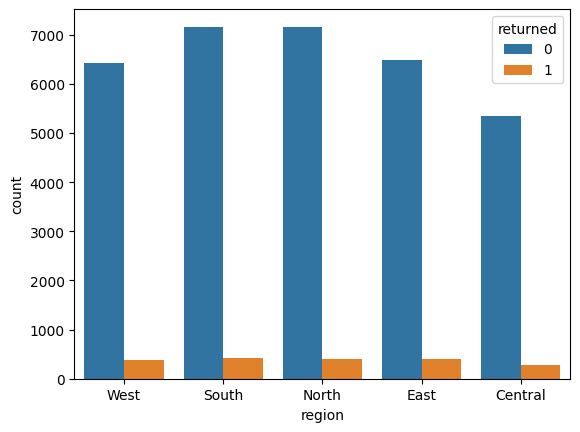

In [33]:
sns.countplot(
    x='region',
    hue='returned',
    data=df
)
plt.show()

The south region had the highest return percentage of 5.5% - 6% whereas Central region had the lowest. Regional customer behavior appears to influence return patterns.

In [34]:
pd.crosstab(
    df['customer_gender'],
    df['returned'],
    normalize='index'
)*100

returned,0,1
customer_gender,,
Female,94.381020,5.618980
Male,94.561619,5.438381
Other,94.825073,5.174927


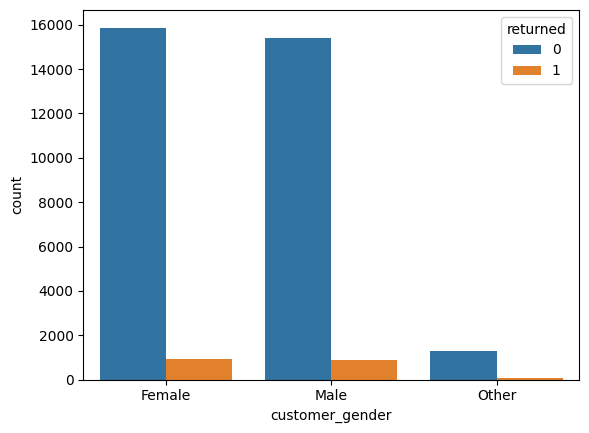

In [35]:
sns.countplot(
    x='customer_gender',
    hue='returned',
    data=df
)
plt.show()

Return rates among male and female customers were 5.4% - 5.8% and 5.7% - 6.0% respectively, suggesting whether gender has an impact on product returns.

In [36]:
df.groupby('returned')['discount'].mean()

,discount
returned,
0,0.049343
1,0.048397


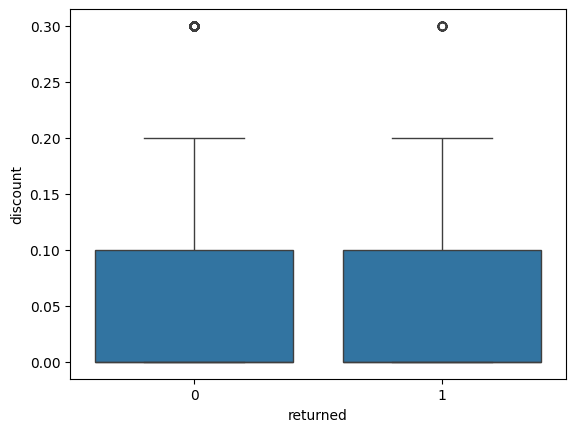

In [37]:
sns.boxplot(
    x='returned',
    y='discount',
    data=df
)
plt.show()

Returned orders received an average discount of ___%, compared to ___% for non-returned orders. This indicates that higher discounts may encourage purchases that are later returned

In [38]:
df.groupby('returned')['price'].mean()

,price
returned,
0,117.889338
1,145.124834


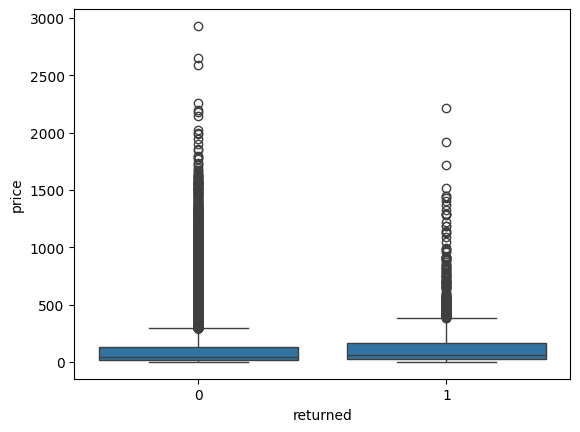

In [39]:
sns.boxplot(
    x='returned',
    y='price',
    data=df
)
plt.show()

The average price of returned products was ₹, compared to ₹ for non-returned products. This suggests whether product price influences return likelihood.

In [40]:
df.groupby('returned')['delivery_days'].mean()

,delivery_days
returned,
0,4.812836
1,4.837625


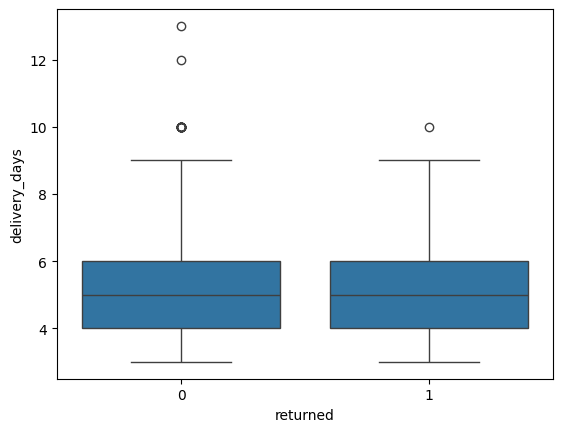

In [41]:
sns.boxplot(
    x='returned',
    y='delivery_days',
    data=df
)
plt.show()

Returned orders had an average delivery time of ___ days compared to ___ days for non-returned orders. Longer delivery times may increase the probability of returns.

Data Preparation for ML

In [42]:
import pandas as pd

In [43]:
df = pd.read_csv("Kaggle_Ecommerce Data.csv")

In [44]:
df.shape

(34500, 19)

In [45]:
df.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivered_date,region,returned,request_date,return_reason,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,23/12/2023,27/12/2023,West,No,NaN,NaN,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,3/4/2025,9/4/2025,South,No,NaN,NaN,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,8/10/2024,12/10/2024,North,No,NaN,NaN,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,14/9/2024,20/9/2024,South,No,NaN,NaN,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,21/12/2024,27/12/2024,East,No,NaN,NaN,13.88,2.74,1.15,39,Male


In [46]:
df.isnull().sum()


,0
order_id,0
customer_id,0
product_id,0
category,0
price,0
discount,0
quantity,0
payment_method,0
order_date,0
delivered_date,0


In [54]:
X = df.drop('returned', axis=1)
y = df['returned']

In [55]:
X = pd.get_dummies(X, drop_first=True)

In [56]:
print(X.shape)
X.head()

(34500, 25)


,price,discount,quantity,total_amount,shipping_cost,profit_margin,customer_age,delivery_days,category_Electronics,category_Fashion,...,payment_method_Debit Card,payment_method_PayPal,payment_method_UPI,payment_method_Wallet,region_East,region_North,region_South,region_West,customer_gender_Male,customer_gender_Other
0,164.08,0.15,1,139.47,7.88,31.17,60,4,False,False,...,False,False,False,False,False,False,False,True,False,False
1,24.73,0.00,1,24.73,4.60,-2.62,37,6,False,False,...,False,False,False,False,False,False,True,False,True,False
2,175.58,0.05,1,166.80,6.58,13.44,34,4,True,False,...,False,False,False,False,False,True,False,False,True,False
3,63.67,0.00,1,63.67,5.50,2.14,21,6,True,False,...,False,False,True,False,False,False,True,False,False,False
4,16.33,0.15,1,13.88,2.74,1.15,39,6,False,False,...,False,False,False,False,True,False,False,False,True,False


In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [58]:
print(X_train.shape)
print(X_test.shape)

(27600, 25)
(6900, 25)


In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [61]:
print(X_train.shape)
print(X_test.shape)

(27600, 25)
(6900, 25)


In [62]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (27600, 25)
X_test: (6900, 25)
y_train: (27600,)
y_test: (6900,)


Model Building : Logistic Regression:

In [63]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [64]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Accuracy: 0.9476811594202899


In [65]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_lr))

[[6539    0]
 [ 361    0]]


In [66]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      6539
           1       0.00      0.00      0.00       361

    accuracy                           0.95      6900
   macro avg       0.47      0.50      0.49      6900
weighted avg       0.90      0.95      0.92      6900



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The Logistic Regression model achieved 94.77% accuracy, but it failed to predict any returned orders (class 1). The confusion matrix shows that all predictions were made as non-returned orders (class 0). This suggests that the dataset is imbalanced, making the high accuracy misleading. Therefore, other models should be tested to improve return prediction.

Decision Tree

In [67]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.8882608695652174
[[6101  438]
 [ 333   28]]
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      6539
           1       0.06      0.08      0.07       361

    accuracy                           0.89      6900
   macro avg       0.50      0.51      0.50      6900
weighted avg       0.90      0.89      0.89      6900



The Decision Tree model achieved 88.83% accuracy. Unlike Logistic Regression, it was able to identify some returned orders (class 1), but its precision and recall for returns were still quite low. This indicates that the model performs better at detecting returns than Logistic Regression, but it still struggles due to the class imbalance in the dataset.

Random Forest

In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9476811594202899
[[6539    0]
 [ 361    0]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      6539
           1       0.00      0.00      0.00       361

    accuracy                           0.95      6900
   macro avg       0.47      0.50      0.49      6900
weighted avg       0.90      0.95      0.92      6900



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The Random Forest model achieved 94.77% accuracy, but like Logistic Regression, it failed to identify any returned orders (class 1). All predictions were made as non-returned orders (class 0). This indicates that the model is affected by the class imbalance in the dataset, making the high accuracy misleading. Therefore, despite its high accuracy, Random Forest is not effectively predicting product returns in its current form.

SVM

In [69]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

svm = SVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.9476811594202899
[[6539    0]
 [ 361    0]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      6539
           1       0.00      0.00      0.00       361

    accuracy                           0.95      6900
   macro avg       0.47      0.50      0.49      6900
weighted avg       0.90      0.95      0.92      6900



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The SVM model achieved 94.77% accuracy, but it failed to predict any returned orders (class 1). All predictions were classified as non-returned orders (class 0). This indicates that the model is affected by the class imbalance in the dataset, making the high accuracy misleading. Therefore, SVM is not effective for return prediction in its current form.

XG BOOST

In [70]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

xgb = XGBClassifier(random_state=42)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.947536231884058
[[6537    2]
 [ 360    1]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      6539
           1       0.33      0.00      0.01       361

    accuracy                           0.95      6900
   macro avg       0.64      0.50      0.49      6900
weighted avg       0.92      0.95      0.92      6900



The XGBoost model achieved 94.75% accuracy. It was able to identify a small number of returned orders (class 1), but the recall and F1-score for the return class remained very low. This indicates that the model is still affected by the class imbalance in the dataset. While XGBoost performed slightly better than Logistic Regression, Random Forest, and SVM in detecting returns, its overall ability to predict returned orders is still limited.

Overall Conclusion:

Among all the models tested, Logistic Regression, Random Forest, SVM, and XGBoost achieved high accuracy (around 95%), but they failed to effectively identify returned orders because of the class imbalance in the dataset. Decision Tree achieved lower accuracy (88.83%) but was able to detect returned orders, making it more useful for this business problem. Since the goal of the project is to predict product returns rather than just achieve high accuracy, Decision Tree is the preferred model. The other models are not suitable in their current form because they mostly predicted the majority class (non-returned orders) and failed to capture the minority return cases.

We can also consider XGBoost because it achieved high accuracy and was able to detect some returned orders. However, its return detection performance was still limited due to class imbalance. Decision Tree remains more suitable for this business problem because it identified a larger number of returned orders, which is the primary objective of the project.